## PDF to Image


In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# from pathlib import Path
# import random
# from collections import defaultdict
# from config.settings import cfg

# root = cfg.DATA_DIR
# sample_size = 250

# # Lấy danh sách PDF theo folder
# folder_pdfs = {}

# for folder in root.iterdir():
#     if folder.is_dir():
#         pdfs = list(folder.rglob("*.pdf"))
#         folder_pdfs[folder.name] = pdfs

# # Tổng số PDF
# total_pdfs = sum(len(v) for v in folder_pdfs.values())

# selected_files = []

# for folder_name, pdfs in folder_pdfs.items():
#     ratio = len(pdfs) / total_pdfs

#     # số lượng cần lấy theo tỷ lệ
#     n = round(sample_size * ratio)

#     # tránh lấy quá số file hiện có
#     n = min(n, len(pdfs))

#     selected_files.extend(random.sample(pdfs, n))

# print(f"Selected {len(selected_files)} files")
# selected_files

In [12]:
# from config.settings import cfg

# total = 0
# for pdf_path in selected_files:
#     saved = pdf_to_image(pdf_path, cfg.OUTPUT_DATA_DIR)
#     total += len(saved)
#     print("Total file: ", total)


In [13]:
from fipilot.resume_extraction import ResumeExtract
from fipilot.config.settings import cfg
extractor = ResumeExtract(
    yolo_model=cfg.YOLO_MODEL,
    llm_model=cfg.LLM_MODEL,
    dpi=300,
    max_workers=cfg.MAX_WORKER,
    max_retries=cfg.MAX_RETRIES
)

pdf_path = "/home/hoai/user/resource/fipilot/backend/test/2.pdf"
# pdf_path = "/home/hoai/Downloads/1/AIE_hoainh.pdf"

saved_files = extractor.pdf_to_images(pdf_path, cfg.PAGE_IMAGE_DIR, overwrite=True) 
saved_files

[PosixPath('/home/hoai/user/resource/fipilot/backend/test/page_image/2_page_1.png'),
 PosixPath('/home/hoai/user/resource/fipilot/backend/test/page_image/2_page_2.png'),
 PosixPath('/home/hoai/user/resource/fipilot/backend/test/page_image/2_page_3.png')]

## Layout Detection 

In [14]:
resume_layout = extractor.layout_detection(pdf_path)
resume_layout

{'2_page_1.png': [[106.87078857421875,
   227.79208374023438,
   2501.369873046875,
   642.6509399414062],
  [121.4428482055664,
   220.09829711914062,
   2426.303466796875,
   746.3817749023438],
  [213.25070190429688, 753.8785400390625, 2200.400390625, 2638.427734375]],
 '2_page_2.png': [[196.293212890625,
   247.67538452148438,
   2249.611572265625,
   3024.048583984375]],
 '2_page_3.png': [[114.90028381347656,
   209.22911071777344,
   2299.513671875,
   1142.1170654296875]]}

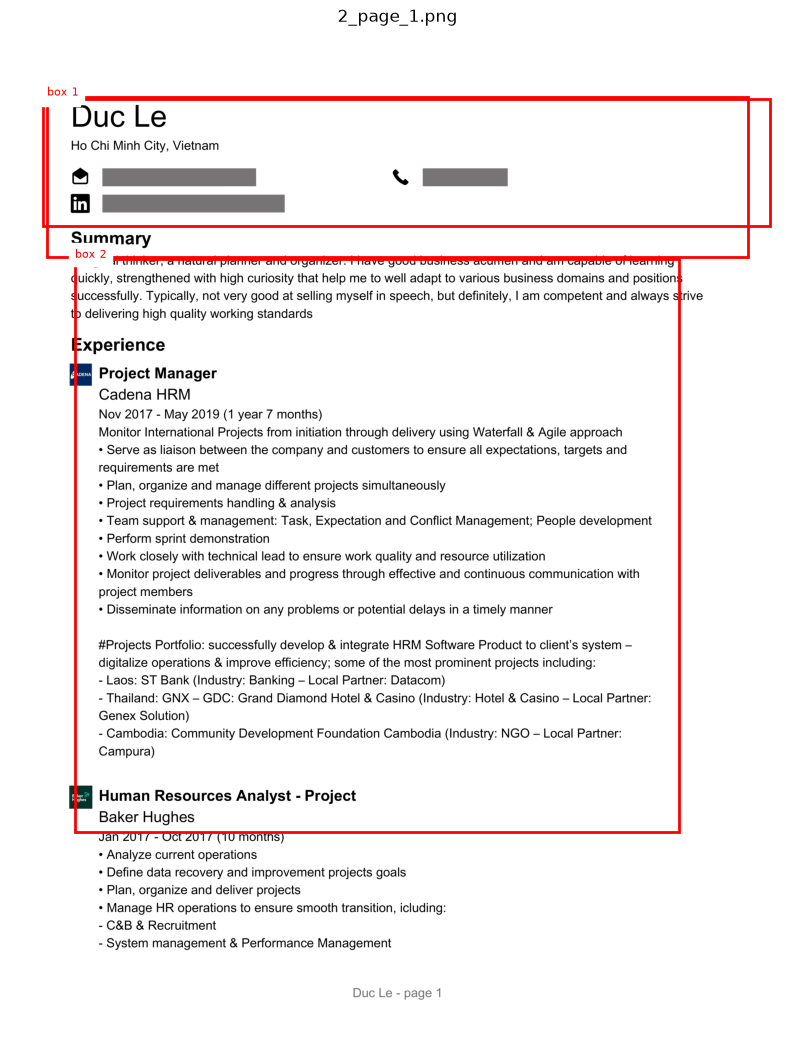

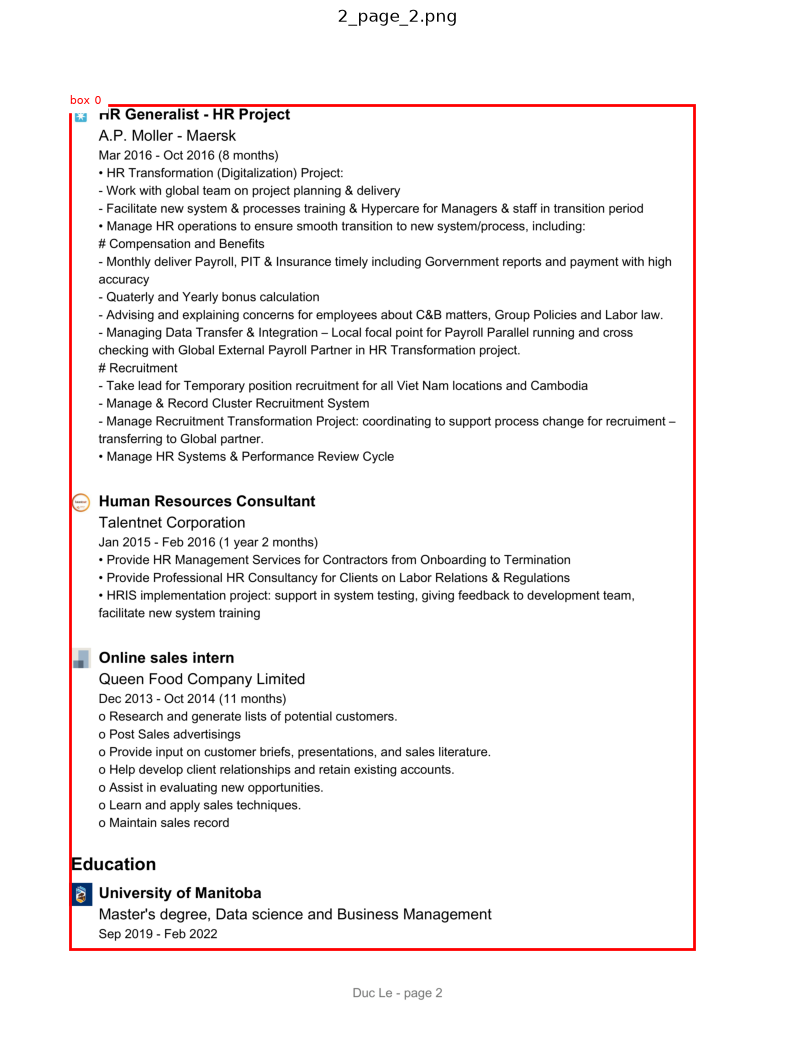

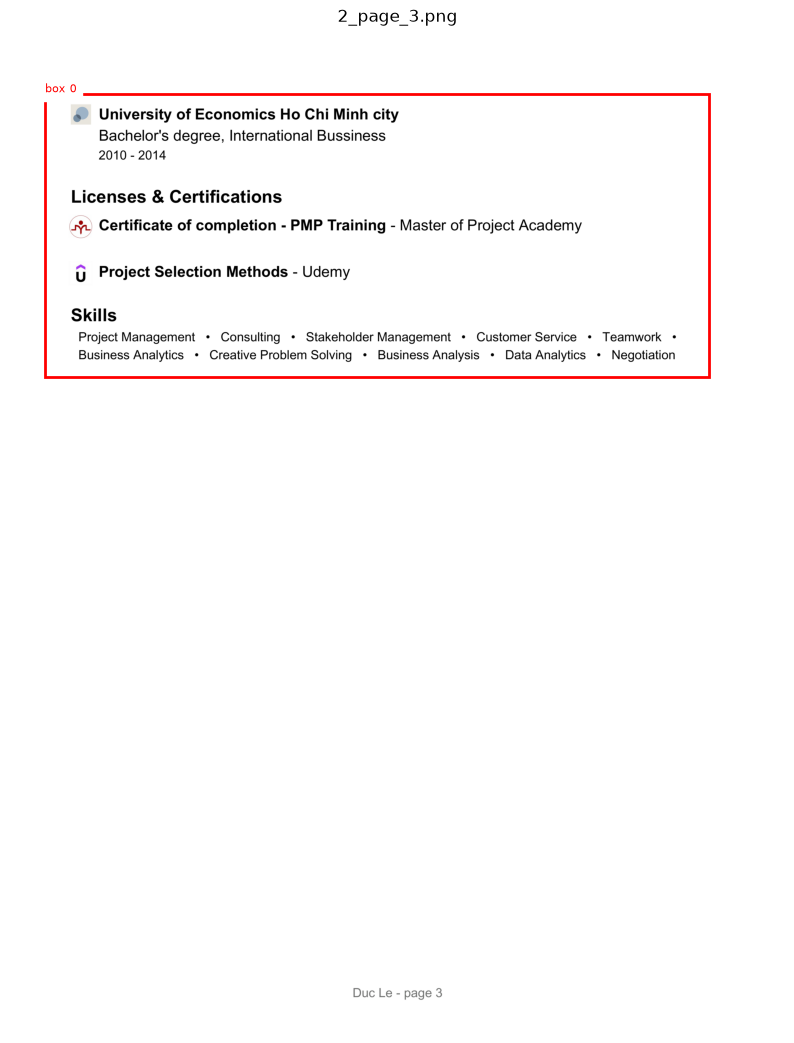

In [15]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

def visualize_layout(image_path, detections: dict, class_names: dict = None):
    """
    image_path: đường dẫn ảnh gốc
    detections: output từ layout_detection(), key là image_name
    class_names: {0: 'header', 1: 'education', ...} — optional
    """
    image_path = Path(image_path)
    xyxy = detections.get(image_path.name)
    
    if xyxy is None:
        print(f"Không tìm thấy detection cho {image_path.name}")
        return

    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(10, 15))
    ax.imshow(img_rgb)

    # xyxy có thể là tensor hoặc numpy
    if hasattr(xyxy, 'cpu'):
        boxes = xyxy.cpu().numpy()
    else:
        boxes = xyxy

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box[:4]
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        label = class_names[i] if class_names else f"box {i}"
        ax.text(x1, y1 - 5, label, color='red', fontsize=8,
                backgroundcolor='white')

    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

for image_path in saved_files:
    visualize_layout(image_path, resume_layout)

In [16]:
all_boxes = extractor.remove_duplicate_boxes(resume_layout)
all_boxes


{'2_page_1.png': [[121.4428482055664,
   220.09829711914062,
   2426.303466796875,
   746.3817749023438],
  [213.25070190429688, 753.8785400390625, 2200.400390625, 2638.427734375]],
 '2_page_2.png': [[196.293212890625,
   247.67538452148438,
   2249.611572265625,
   3024.048583984375]],
 '2_page_3.png': [[114.90028381347656,
   209.22911071777344,
   2299.513671875,
   1142.1170654296875]]}

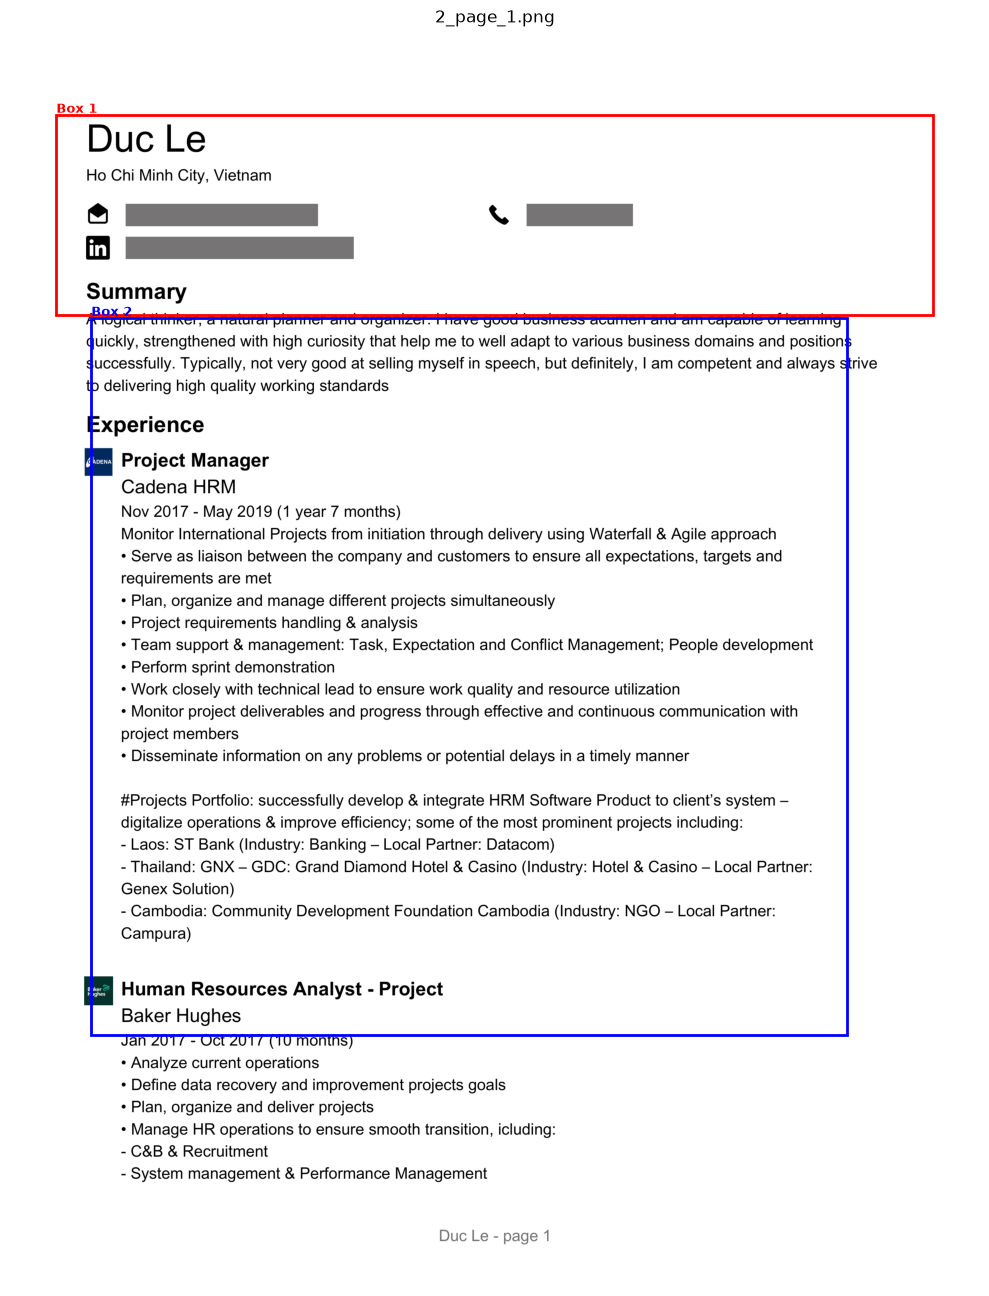

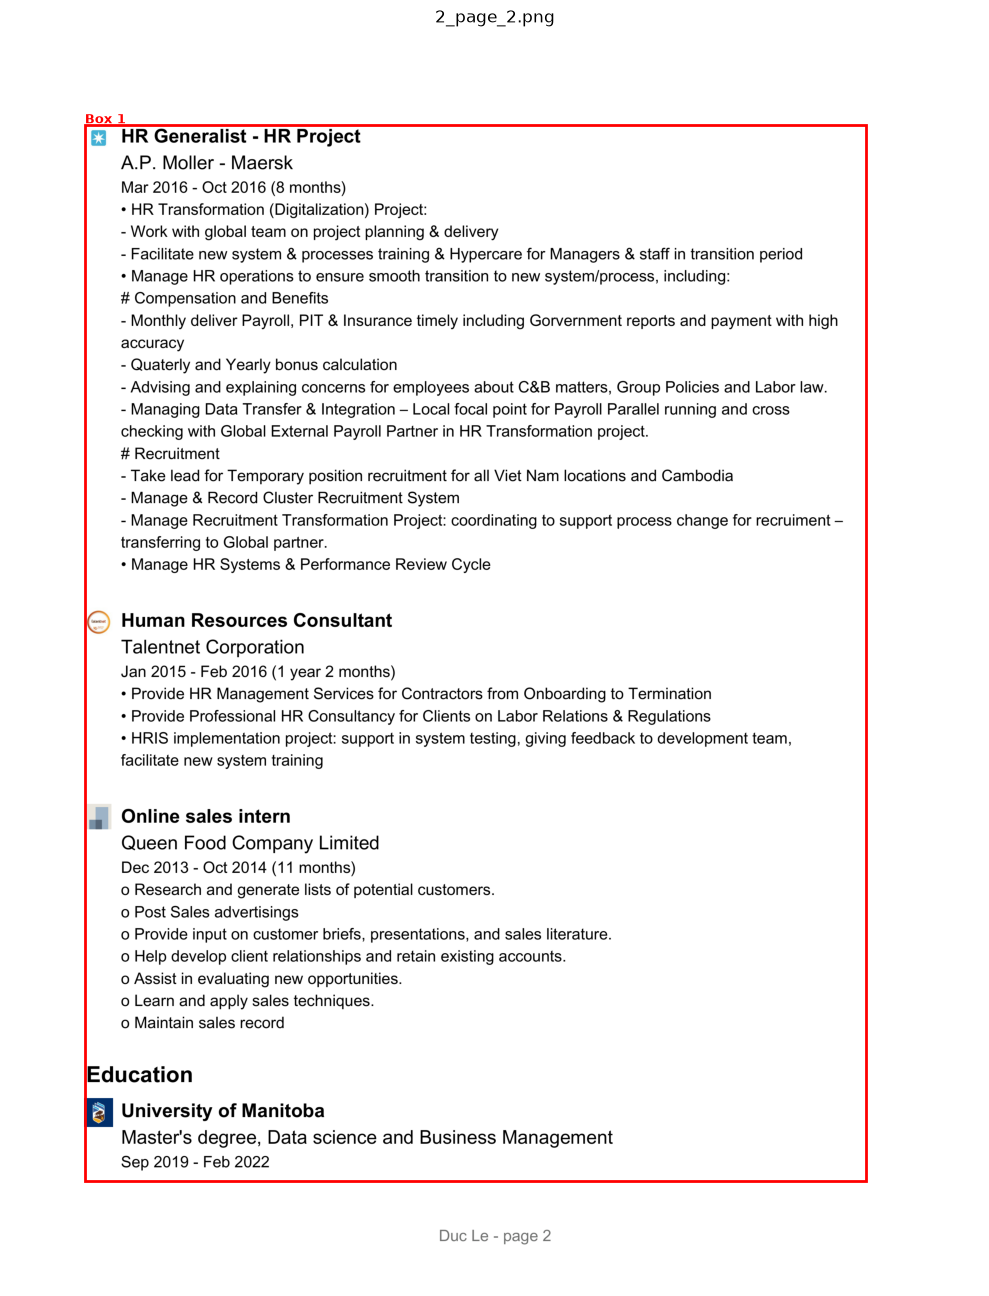

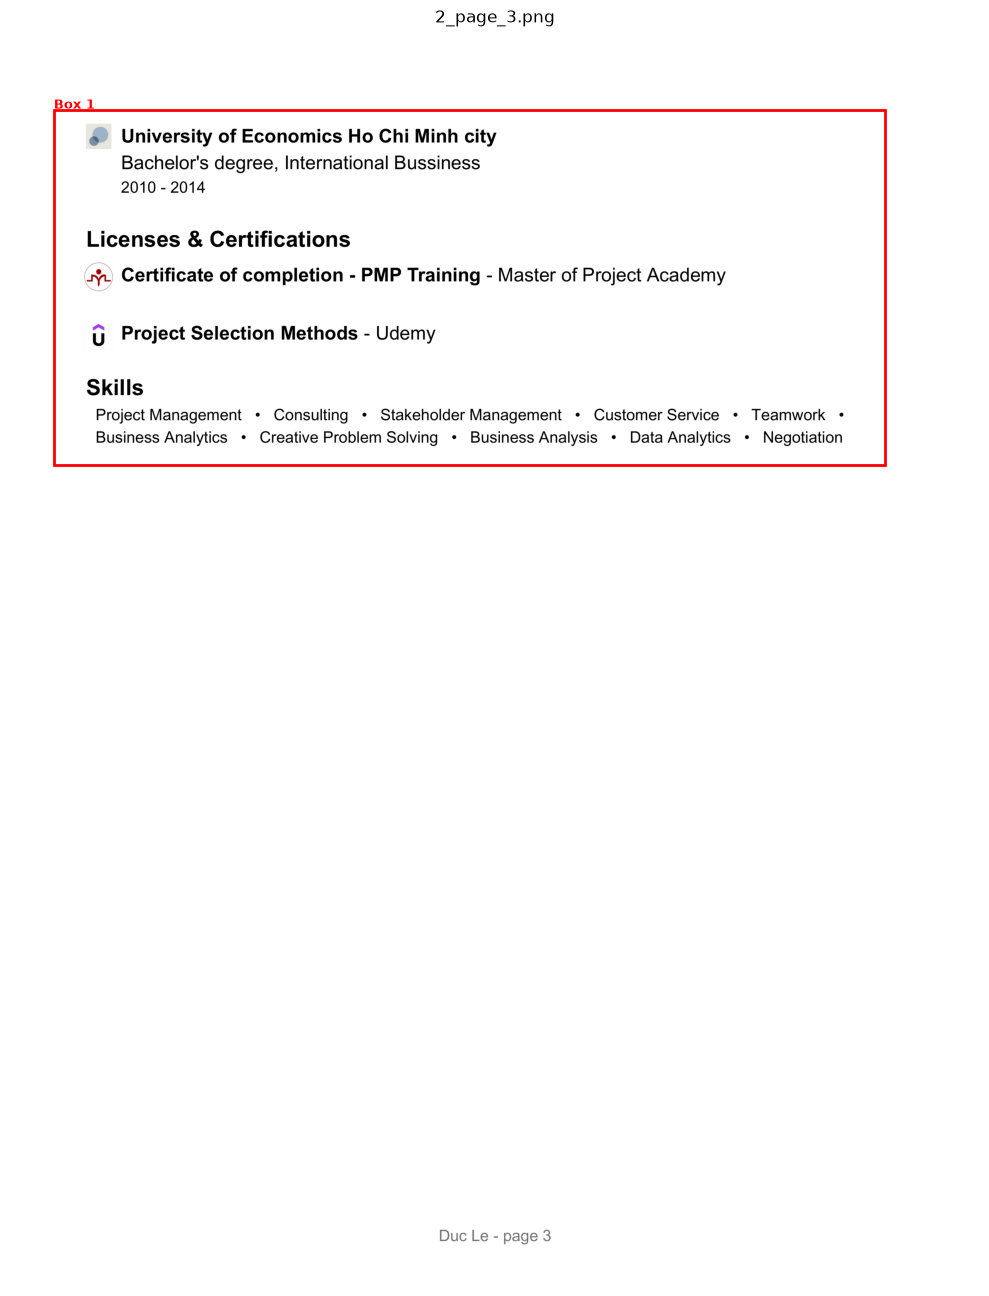

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from pathlib import Path

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

image_dir = {path.name: path for path in saved_files}

for image_name, boxes in all_boxes.items():

    img = mpimg.imread(image_dir[image_name])

    fig, ax = plt.subplots(figsize=(10, 15))
    ax.imshow(img)

    for i, box in enumerate(boxes):

        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=colors[i % len(colors)],
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(0, y1 - 5),
            f"Box {i + 1}",
            color=colors[i % len(colors)],
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(image_name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Sorting and Map metadata

In [18]:
inter_boxes = extractor.inter_segment_sorting(all_boxes)
inter_boxes

{'2_page_1.png': [[121.4428482055664,
   220.09829711914062,
   2426.303466796875,
   746.3817749023438],
  [213.25070190429688, 753.8785400390625, 2200.400390625, 2638.427734375]],
 '2_page_2.png': [[196.293212890625,
   247.67538452148438,
   2249.611572265625,
   3024.048583984375]],
 '2_page_3.png': [[114.90028381347656,
   209.22911071777344,
   2299.513671875,
   1142.1170654296875]]}

In [19]:
resume = extractor.pair_resume(pdf_path)
resume

{'2_page_1.png': [{'bbox': (200.0,
    209.8166624704997,
    516.700013478597,
    350.5166371663412),
   'text': 'Duc Le'},
  {'bbox': (200.0, 349.22917683919275, 688.2083257039388, 407.854175567627),
   'text': 'Ho Chi Minh City, Vietnam'},
  {'bbox': (200.0, 646.1083730061849, 465.7083829243978, 726.9583384195964),
   'text': 'Summary'},
  {'bbox': (200.0, 726.6875584920248, 2186.1241658528647, 785.3125254313152),
   'text': 'A logical thinker, a natural planner and organizer. I have good business acumen and am capable of learning'},
  {'bbox': (200.0, 785.0208918253581, 2213.6660257975263, 843.6458587646486),
   'text': 'quickly, strengthened with high curiosity that help me to well adapt to various business domains and positions'},
  {'bbox': (200.0, 843.3542251586915, 2280.457305908203, 901.9791920979818),
   'text': 'successfully. Typically, not very good at selling myself in speech, but definitely, I am competent and always strive'},
  {'bbox': (200.0, 901.6875584920248, 996.2

In [20]:
intra_boxes = extractor.intra_segment_sorting(inter_boxes, resume)
intra_boxes

[{'image': '2_page_1.png',
  'bbox': [121.4428482055664,
   220.09829711914062,
   2426.303466796875,
   746.3817749023438],
  'contained_blocks': [{'bbox': (200.0,
     209.8166624704997,
     516.700013478597,
     350.5166371663412),
    'text': 'Duc Le'},
   {'bbox': (200.0, 349.22917683919275, 688.2083257039388, 407.854175567627),
    'text': 'Ho Chi Minh City, Vietnam'},
   {'bbox': (200.0, 646.1083730061849, 465.7083829243978, 726.9583384195964),
    'text': 'Summary'}]},
 {'image': '2_page_1.png',
  'bbox': [213.25070190429688,
   753.8785400390625,
   2200.400390625,
   2638.427734375],
  'contained_blocks': [{'bbox': (200.0,
     726.6875584920248,
     2186.1241658528647,
     785.3125254313152),
    'text': 'A logical thinker, a natural planner and organizer. I have good business acumen and am capable of learning'},
   {'bbox': (200.0, 785.0208918253581, 2213.6660257975263, 843.6458587646486),
    'text': 'quickly, strengthened with high curiosity that help me to well adapt

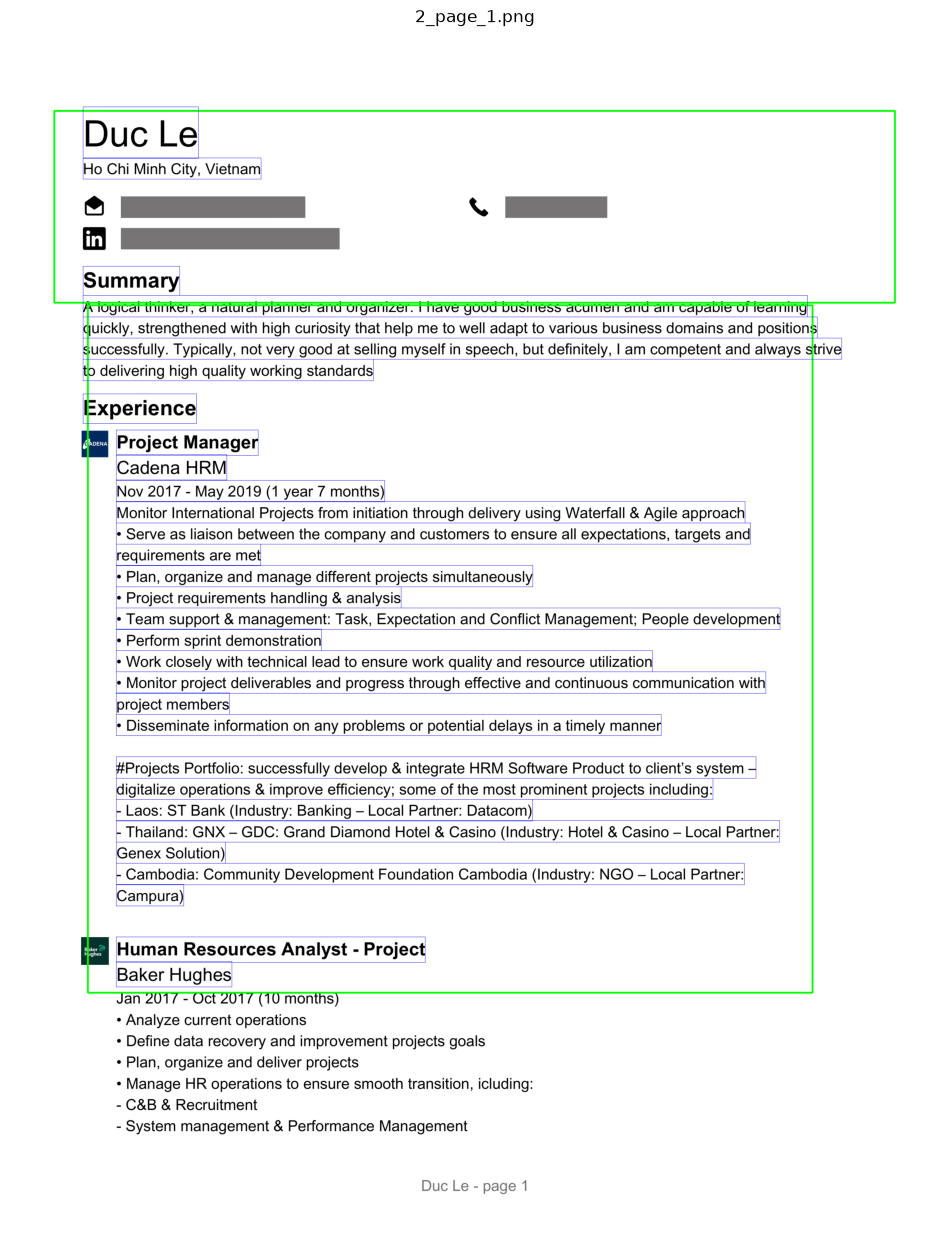

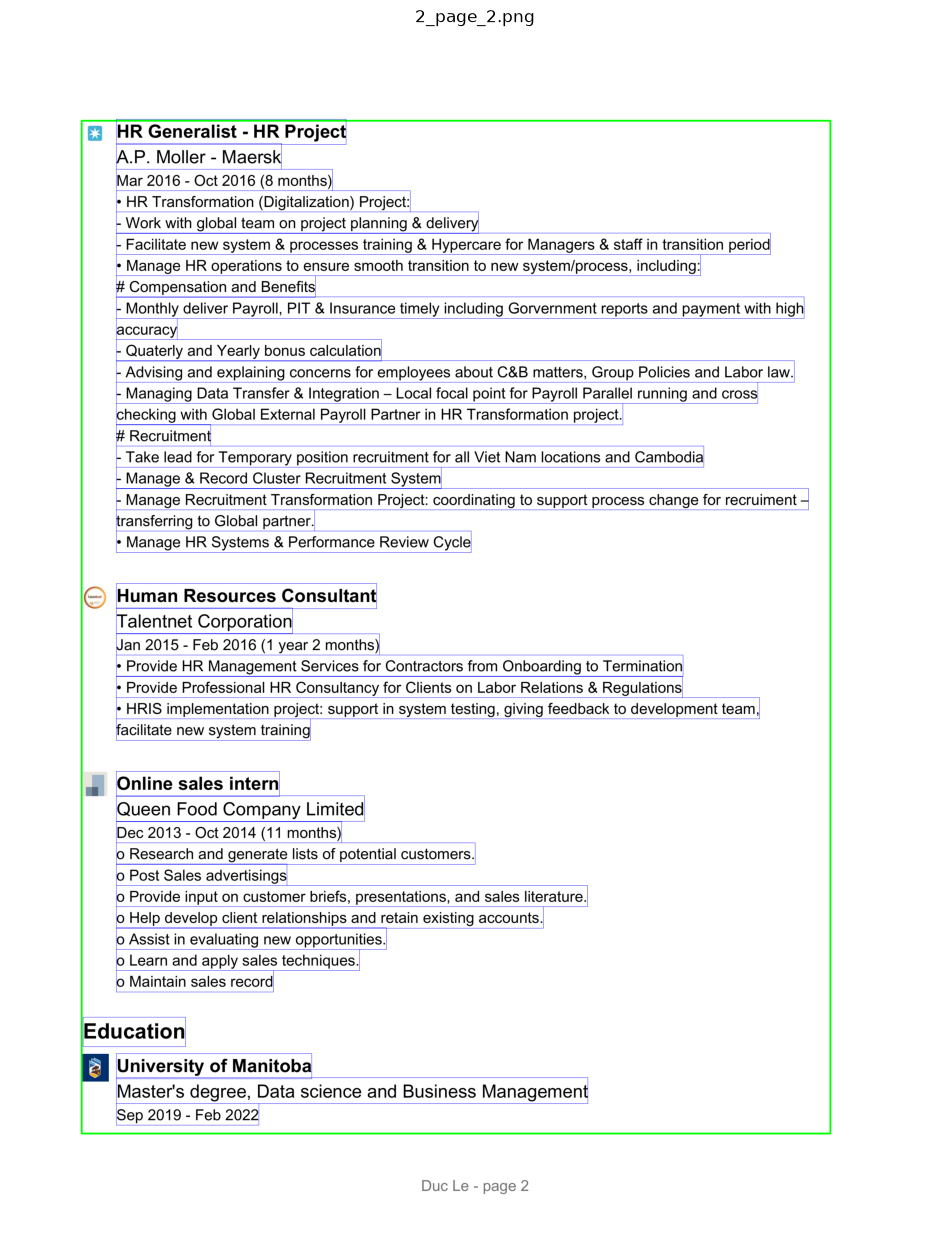

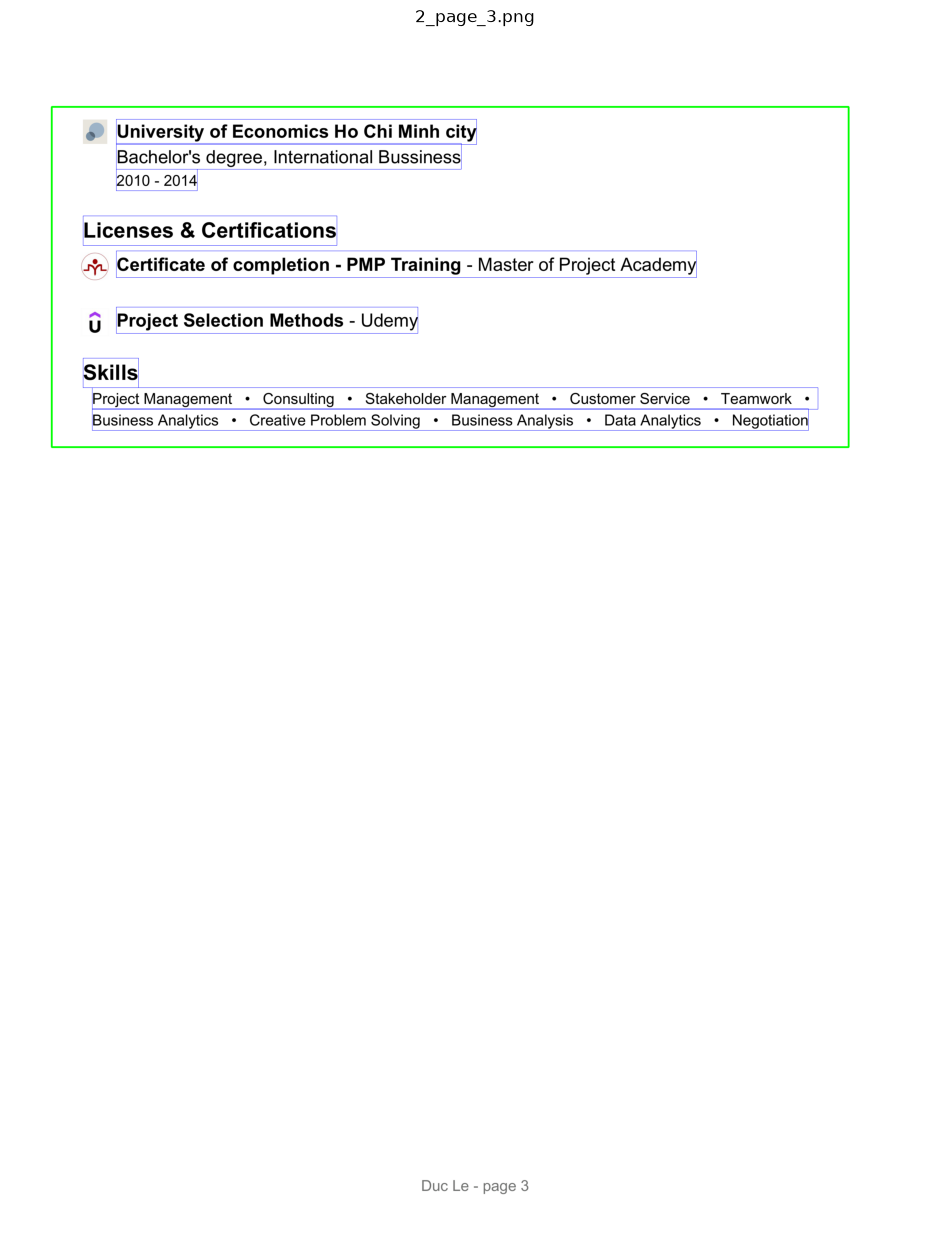

In [21]:
from collections import defaultdict
import cv2
import matplotlib.pyplot as plt

image_lookup = {path.name: path for path in saved_files}

grouped = defaultdict(list)
for region in intra_boxes:
    grouped[region["image"]].append(region)

for image_name, regions in grouped.items():
    img = cv2.imread(str(image_lookup[image_name]))
    
    for region in regions:
        # YOLO bbox (xanh lá)
        x1, y1, x2, y2 = map(int, region["bbox"])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Contained blocks (xanh dương)
        for block in region["contained_blocks"]:
            bx1, by1, bx2, by2 = map(int, block["bbox"])
            cv2.rectangle(img, (bx1, by1), (bx2, by2), (255, 0, 0), 1)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 16))
    plt.title(image_name)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [22]:
linearized_text = extractor.linearize_layout_regions(intra_boxes)
print(linearized_text)

[0]: Duc Le [1]: Ho Chi Minh City, Vietnam [2]: Summary [3]: A logical thinker, a natural planner and organizer. I have good business acumen and am capable of learning [4]: quickly, strengthened with high curiosity that help me to well adapt to various business domains and positions [5]: successfully. Typically, not very good at selling myself in speech, but definitely, I am competent and always strive [6]: to delivering high quality working standards [7]: Experience [8]: Project Manager [9]: Cadena HRM [10]: Nov 2017 - May 2019 (1 year 7 months) [11]: Monitor International Projects from initiation through delivery using Waterfall & Agile approach [12]: - Serve as liaison between the company and customers to ensure all expectations, targets and [13]: requirements are met [14]: - Plan, organize and manage different projects simultaneously [15]: - Project requirements handling & analysis [16]: - Team support & management: Task, Expectation and Conflict Management; People development [17]